# **PORTFOLIO MANAGEMENT - CAPM AND FAMA-FRENCH**
## Prepared by LINH HA and ANTON MAKAROV (University of Luxembourg)

All rights reserved.

In [1]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)


### **Data preparation**
- *Test assets*: 10 industry portfolios, 25 size/book-to-market portfolios, and 6 size/book-to-market portfolios.
- *Factors*: market excess return (`Mkt-RF`), size (`SMB`), value (`HML`), and the risk-free rate (`RF`).
- *Period*: July 1963 onward, using the available common sample for each analysis.
- *Frequency*: monthly.

In [1]:
# !pip install numpy pandas matplotlib scipy statsmodels requests

from io import BytesIO, StringIO
from pathlib import Path
from zipfile import ZipFile
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import statsmodels.api as sm
from scipy import stats
from IPython.display import display
from matplotlib.ticker import PercentFormatter


#### **Sample settings**

In [2]:
# Choose the data source, test asset, and estimation window

DATA_MODE = "auto"  # "auto", "bundled", "live", or "synthetic"
ANALYSIS_START = pd.Timestamp("1963-07-01")
SELECTED_ASSET = "HiTec"  # one of the ten industry portfolios
ROLLING_WINDOW = 60  # months used in rolling first-pass regressions
RANDOM_SEED = 20260820


In [7]:
# Display

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("default")


#### **Downloading and preparing the monthly returns**

The loader looks for the bundled files in a local `data/` directory first. If they are missing it tries a live download from the Kenneth French Data Library, and if that fails too it falls back to a deterministic synthetic dataset so the notebook still runs end to end. The printout below says which source was actually used — check it before interpreting any numbers.

The bundled snapshots come from different vintages, which is why the analyses involving the 25 size/book-to-market portfolios end earlier than those using the factor and industry files.

In [8]:
# Kenneth French Data Library download links

OFFICIAL_URLS = {
    "factors": "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_CSV.zip",
    "industries": "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/10_Industry_Portfolios_CSV.zip",
    "portfolios25": "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/25_Portfolios_5x5_CSV.zip",
    "portfolios6": "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/6_Portfolios_2x3_CSV.zip",
}


Function `parse_first_monthly_table` reads monthly observations and converts percentage returns to decimals.

In [9]:
def parse_first_monthly_table(
    text: str, marker: str | None = None
) -> pd.DataFrame:
    """Parse the first six-digit monthly table in a Kenneth French CSV-like file."""
    lines = text.replace("\r\n", "\n").replace("\r", "\n").split("\n")
    start_search = 0

    if marker is not None:
        for line_number, line in enumerate(lines):
            if marker.lower() in line.lower():
                start_search = line_number + 1
                break

    header_index = None
    for line_number in range(start_search, len(lines)):
        line = lines[line_number]
        if line.lstrip().startswith(",") and len(line.split(",")) >= 2:
            header_index = line_number
            break

    if header_index is None:
        raise ValueError("Could not locate the monthly table header.")

    data_lines: list[str] = []
    for line in lines[header_index + 1 :]:
        first_field = line.split(",", 1)[0].strip()
        if re.fullmatch(r"\d{6}", first_field):
            data_lines.append(line)
        elif data_lines:
            break

    if not data_lines:
        raise ValueError("Could not locate monthly observations.")

    frame = pd.read_csv(StringIO("\n".join([lines[header_index], *data_lines])))
    frame.rename(columns={frame.columns[0]: "Date"}, inplace=True)
    frame["Date"] = pd.to_datetime(
        frame["Date"].astype(str).str.strip(), format="%Y%m"
    )
    frame.set_index("Date", inplace=True)
    frame.columns = [str(column).strip() for column in frame.columns]
    frame = frame.apply(pd.to_numeric, errors="coerce")
    frame = frame.replace([-99.99, -999, -99, -999.99], np.nan) / 100.0
    return frame.sort_index()


Function `parse_six_portfolios` gives the six size/book-to-market portfolios consistent column names.

In [10]:
def parse_six_portfolios(text: str) -> pd.DataFrame:
    """Parse the six 2x3 size/book-to-market portfolios, with or without a header."""
    first_nonempty = next(line for line in text.splitlines() if line.strip())
    standard_names = [
        "Date",
        "Small Low",
        "Small Neutral",
        "Small High",
        "Big Low",
        "Big Neutral",
        "Big High",
    ]

    if re.match(r"^\s*\d{6}\s*,", first_nonempty):
        frame = pd.read_csv(StringIO(text), header=None, names=standard_names)
        frame["Date"] = pd.to_datetime(frame["Date"].astype(str), format="%Y%m")
        frame.set_index("Date", inplace=True)
        return frame.apply(pd.to_numeric, errors="coerce") / 100.0

    frame = parse_first_monthly_table(
        text, marker="Average Value Weighted Returns -- Monthly"
    )
    if frame.shape[1] != 6:
        raise ValueError(
            f"Expected six 2x3 portfolios, found {frame.shape[1]} columns."
        )
    frame.columns = standard_names[1:]
    return frame


Function `fetch_zipped_csv_text` downloads and opens a compressed data file.

In [11]:
def fetch_zipped_csv_text(url: str, timeout: int = 30) -> str:
    """Download a Kenneth French ZIP and return the first CSV/TXT member as text."""
    response = requests.get(url, timeout=timeout)
    response.raise_for_status()
    with ZipFile(BytesIO(response.content)) as archive:
        members = [
            name
            for name in archive.namelist()
            if name.lower().endswith((".csv", ".txt"))
        ]
        if not members:
            members = archive.namelist()
        if not members:
            raise ValueError("The downloaded archive was empty.")
        raw = archive.read(members[0])
    try:
        return raw.decode("utf-8")
    except UnicodeDecodeError:
        return raw.decode("latin-1")


Function `find_local_file` checks the notebook folder and its `data/` subfolder for a saved file.

In [12]:
def find_local_file(filename: str) -> Path | None:
    candidates = [Path("data") / filename, Path.cwd() / filename]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


#### **Synthetic data for offline practice**

Function `make_synthetic_bundle` supplies reproducible practice data when the original observations are unavailable.

In [ ]:
def make_synthetic_bundle(seed: int = RANDOM_SEED) -> dict[str, pd.DataFrame]:
    """Create a fallback dataset."""
    rng = np.random.default_rng(seed)
    dates = pd.date_range("1963-07-01", "2024-12-01", freq="MS")
    n_months = len(dates)

    factor_means = np.array([0.0055, 0.0018, 0.0025])
    factor_cov = np.array(
        [
            [0.045**2, 0.00025, -0.00010],
            [0.00025, 0.030**2, 0.00008],
            [-0.00010, 0.00008, 0.032**2],
        ]
    )
    factor_draws = rng.multivariate_normal(
        factor_means, factor_cov, size=n_months
    )
    rf = np.clip(rng.normal(0.0020, 0.0012, n_months), -0.0010, 0.0080)
    factors = pd.DataFrame(
        factor_draws, index=dates, columns=["Mkt-RF", "SMB", "HML"]
    )
    factors["RF"] = rf

    industry_names = [
        "NoDur",
        "Durbl",
        "Manuf",
        "Enrgy",
        "HiTec",
        "Telcm",
        "Shops",
        "Hlth",
        "Utils",
        "Other",
    ]
    industry_loadings = np.array(
        [
            [0.78, -0.10, 0.15],
            [1.25, 0.20, 0.30],
            [1.05, 0.02, 0.18],
            [0.86, -0.12, 0.50],
            [1.23, 0.20, -0.50],
            [0.78, -0.18, 0.15],
            [1.00, 0.08, -0.05],
            [0.82, -0.20, -0.28],
            [0.53, -0.20, 0.30],
            [1.10, 0.05, 0.40],
        ]
    )
    industry_alpha = np.array(
        [
            0.0015,
            -0.0005,
            0.0002,
            0.0010,
            0.0003,
            0.0001,
            0.0010,
            0.0015,
            0.0010,
            -0.0002,
        ]
    )
    industry_noise = rng.normal(
        0.0, 0.030, size=(n_months, len(industry_names))
    )
    industry_excess = (
        industry_alpha + factor_draws @ industry_loadings.T + industry_noise
    )
    industries = pd.DataFrame(
        industry_excess + rf[:, None], index=dates, columns=industry_names
    )

    portfolio_columns: list[str] = []
    portfolio_loadings: list[list[float]] = []
    for size in range(1, 6):
        for bm in range(1, 6):
            if size == 1 and bm == 1:
                name = "SMALL LoBM"
            elif size == 1 and bm == 5:
                name = "SMALL HiBM"
            elif size == 5 and bm == 1:
                name = "BIG LoBM"
            elif size == 5 and bm == 5:
                name = "BIG HiBM"
            else:
                name = f"ME{size} BM{bm}"
            portfolio_columns.append(name)
            beta = 1.20 - 0.06 * (size - 1) + 0.02 * (3 - bm)
            smb_loading = 1.00 - 0.38 * (size - 1)
            hml_loading = -0.80 + 0.40 * (bm - 1)
            portfolio_loadings.append([beta, smb_loading, hml_loading])

    portfolio_loadings_array = np.asarray(portfolio_loadings)
    portfolio_noise = rng.normal(0.0, 0.035, size=(n_months, 25))
    p25_excess = factor_draws @ portfolio_loadings_array.T + portfolio_noise
    portfolios25 = pd.DataFrame(
        p25_excess + rf[:, None], index=dates, columns=portfolio_columns
    )

    six_names = [
        "Small Low",
        "Small Neutral",
        "Small High",
        "Big Low",
        "Big Neutral",
        "Big High",
    ]
    six_loadings = np.array(
        [
            [1.15, 1.00, -0.80],
            [1.10, 1.00, 0.00],
            [1.05, 1.00, 0.80],
            [1.00, -0.20, -0.80],
            [0.95, -0.20, 0.00],
            [0.90, -0.20, 0.80],
        ]
    )
    six_noise = rng.normal(0.0, 0.015, size=(n_months, 6))
    six_excess = factor_draws @ six_loadings.T + six_noise
    portfolios6 = pd.DataFrame(
        six_excess + rf[:, None], index=dates, columns=six_names
    )

    return {
        "factors": factors,
        "industries": industries,
        "portfolios25": portfolios25,
        "portfolios6": portfolios6,
    }


#### **Selecting the data source**

Function `load_data_bundle` selects the local files, a live download, or synthetic practice data according to `DATA_MODE`.

In [14]:
def load_data_bundle(
    mode: str = DATA_MODE,
) -> tuple[dict[str, pd.DataFrame], str]:
    mode = mode.lower()
    if mode not in {"auto", "bundled", "live", "synthetic"}:
        raise ValueError(
            "DATA_MODE must be 'auto', 'bundled', 'live', or 'synthetic'."
        )

    local_names = {
        "factors": "F-F_Research_Data_Factors.CSV",
        "industries": "10_Industry_Portfolios.CSV",
        "portfolios25": "25_Portfolios_5x5.CSV",
        "portfolios6": "6_Portfolios_2x3.csv",
    }

    if mode in {"auto", "bundled"}:
        local_paths = {
            key: find_local_file(filename)
            for key, filename in local_names.items()
        }
        if all(path is not None for path in local_paths.values()):
            factors = parse_first_monthly_table(
                local_paths["factors"].read_text(errors="replace")
            )
            industries = parse_first_monthly_table(
                local_paths["industries"].read_text(errors="replace"),
                marker="Average Value Weighted Returns -- Monthly",
            )
            portfolios25 = parse_first_monthly_table(
                local_paths["portfolios25"].read_text(errors="replace"),
                marker="Average Value Weighted Returns -- Monthly",
            )
            portfolios6 = parse_six_portfolios(
                local_paths["portfolios6"].read_text(errors="replace")
            )
            bundle = {
                "factors": factors,
                "industries": industries,
                "portfolios25": portfolios25,
                "portfolios6": portfolios6,
            }
            return bundle, "bundled offline Kenneth French snapshots"
        if mode == "bundled":
            missing = [
                filename
                for key, filename in local_names.items()
                if local_paths[key] is None
            ]
            raise FileNotFoundError(
                f"Bundled mode requested, but these files are missing: {missing}"
            )

    if mode in {"auto", "live"}:
        try:
            factor_text = fetch_zipped_csv_text(OFFICIAL_URLS["factors"])
            industry_text = fetch_zipped_csv_text(OFFICIAL_URLS["industries"])
            p25_text = fetch_zipped_csv_text(OFFICIAL_URLS["portfolios25"])
            p6_text = fetch_zipped_csv_text(OFFICIAL_URLS["portfolios6"])
            bundle = {
                "factors": parse_first_monthly_table(factor_text),
                "industries": parse_first_monthly_table(
                    industry_text, "Average Value Weighted Returns -- Monthly"
                ),
                "portfolios25": parse_first_monthly_table(
                    p25_text, "Average Value Weighted Returns -- Monthly"
                ),
                "portfolios6": parse_six_portfolios(p6_text),
            }
            return bundle, "live Kenneth French Data Library download"
        except Exception as exc:
            if mode == "live":
                raise RuntimeError("Live data download failed.") from exc
            print(
                f"Live download unavailable ({type(exc).__name__}: {exc}). Using synthetic fallback."
            )

    return make_synthetic_bundle(), "deterministic synthetic fallback"


- Load and clean the four datasets:

In [15]:
bundle, DATA_SOURCE = load_data_bundle()

factors = bundle["factors"].copy()
industries = bundle["industries"].copy()
portfolios25 = bundle["portfolios25"].copy()
portfolios6 = bundle["portfolios6"].copy()

# Normalize minor naming inconsistencies in raw files.
industries.columns = [column.replace(" ", "") for column in industries.columns]
for frame in (factors, industries, portfolios25, portfolios6):
    frame.replace([np.inf, -np.inf], np.nan, inplace=True)
    frame.sort_index(inplace=True)

if SELECTED_ASSET not in industries.columns:
    SELECTED_ASSET = industries.columns[0]


- Check the source and the available sample:

In [16]:
summary_rows = []
for name, frame in {
    "Fama–French factors": factors,
    "10 industry portfolios": industries,
    "25 size/BM portfolios": portfolios25,
    "6 size/BM portfolios": portfolios6,
}.items():
    summary_rows.append(
        {
            "Dataset": name,
            "Rows": len(frame),
            "Columns": frame.shape[1],
            "First month": frame.index.min().strftime("%Y-%m"),
            "Last month": frame.index.max().strftime("%Y-%m"),
        }
    )

print(f"Data source used: {DATA_SOURCE}")
display(pd.DataFrame(summary_rows).set_index("Dataset"))


Data source used: live Kenneth French Data Library download


,Rows,Columns,First month,Last month
Dataset,,,,
Fama–French factors,1202,4,1926-07,2026-08
10 industry portfolios,1202,10,1926-07,2026-08
25 size/BM portfolios,1202,25,1926-07,2026-08
6 size/BM portfolios,1202,6,1926-07,2026-08


A note on units: the raw French files are in percent and the loader divides by 100, so `0.01` means 1% per month. Means and alphas are annualized by multiplying by 12, volatilities by $\sqrt{12}$.

- Preview the monthly factors:

In [17]:
factors.head(3)


,Mkt-RF,SMB,HML,RF
Date,,,,
1926-07-01,0.0289,-0.0242,-0.0275,0.0022
1926-08-01,0.0264,-0.0144,0.0413,0.0025
1926-09-01,0.0038,-0.0136,0.0005,0.0023


- Preview the industry returns:

In [18]:
industries.head(3)


,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other
Date,,,,,,,,,,
1926-07-01,0.0144,0.1558,0.0470,-0.0114,0.0290,0.0083,0.0012,0.0185,0.0704,0.0214
1926-08-01,0.0399,0.0370,0.0280,0.0343,0.0266,0.0217,-0.0072,0.0417,-0.0170,0.0435
1926-09-01,0.0115,0.0498,0.0117,-0.0330,-0.0039,0.0242,0.0021,0.0069,0.0205,0.0031


## **CAPM: BETA ESTIMATION AND EMPIRICAL TESTS**

### **I. Asset beta: the Security Characteristic Line**

For asset or portfolio $i$, the CAPM time-series regression is

$$R_{i,t}-R_{f,t}=\alpha_i+\beta_i\bigl(R_{M,t}-R_{f,t}\bigr)+\varepsilon_{i,t}.$$

The slope is the market beta,

$$\beta_i=\frac{\operatorname{Cov}(R_i-R_f,\,R_M-R_f)}{\operatorname{Var}(R_M-R_f)},$$

and the intercept is Jensen's alpha relative to the chosen benchmark. A beta above one means above-average sensitivity to market movements; below one, a defensive exposure.

Function `fit_time_series_model` regresses excess returns on the selected factors, using HAC standard errors.

In [19]:
def fit_time_series_model(
    asset_return: pd.Series,
    factor_frame: pd.DataFrame,
    factor_columns: list[str],
    start: pd.Timestamp | str = ANALYSIS_START,
    hac_lags: int = 6,
):
    data = (
        asset_return.rename("Asset return")
        .to_frame()
        .join(factor_frame[["RF", *factor_columns]], how="inner")
        .loc[start:]
        .dropna()
    )
    excess_return = data["Asset return"] - data["RF"]
    regressors = sm.add_constant(data[factor_columns])
    model = sm.OLS(excess_return, regressors).fit(
        cov_type="HAC", cov_kwds={"maxlags": hac_lags}
    )
    return model, data, excess_return


- Estimate the asset beta:

In [20]:
asset_model, asset_data, asset_excess = fit_time_series_model(
    industries[SELECTED_ASSET], factors, ["Mkt-RF"]
)


- Verify beta using the covariance formula and calculate the required return:

In [21]:
beta_from_covariance = (
    asset_excess.cov(asset_data["Mkt-RF"]) / asset_data["Mkt-RF"].var()
)
market_premium_monthly = asset_data["Mkt-RF"].mean()
risk_free_monthly = asset_data["RF"].mean()
capm_required_return_monthly = (
    risk_free_monthly + asset_model.params["Mkt-RF"] * market_premium_monthly
)


- Regression coefficients:

In [22]:
coefficient_table = pd.DataFrame(
    {
        "Estimate": asset_model.params,
        "HAC standard error": asset_model.bse,
        "t-statistic": asset_model.tvalues,
        "p-value": asset_model.pvalues,
    }
)
coefficient_table.index = ["Alpha (monthly)", "Market beta"]

print(f"Selected test asset: {SELECTED_ASSET}")
display(coefficient_table.round(4))


Selected test asset: HiTec


,Estimate,HAC standard error,t-statistic,p-value
Alpha (monthly),0.0002,0.0013,0.1882,0.8507
Market beta,1.2349,0.0434,28.4656,0.0000


- Alpha, required return, and model fit:

In [23]:
diagnostics = pd.DataFrame(
    {
        "Value": {
            "Beta from regression": asset_model.params["Mkt-RF"],
            "Beta from Cov/Var": beta_from_covariance,
            "Annualized alpha": 12 * asset_model.params["const"],
            "Annualized sample return": 12 * asset_data["Asset return"].mean(),
            "Annualized CAPM required return": 12
            * capm_required_return_monthly,
            "Adjusted R-squared": asset_model.rsquared_adj,
            "Observations": int(asset_model.nobs),
        }
    }
)
display(diagnostics.round(4))


,Value
Beta from regression,1.2349
Beta from Cov/Var,1.2349
Annualized alpha,0.0028
Annualized sample return,0.1356
Annualized CAPM required return,0.1327
Adjusted R-squared,0.7496
Observations,758.0000


#### **Security Characteristic Line**

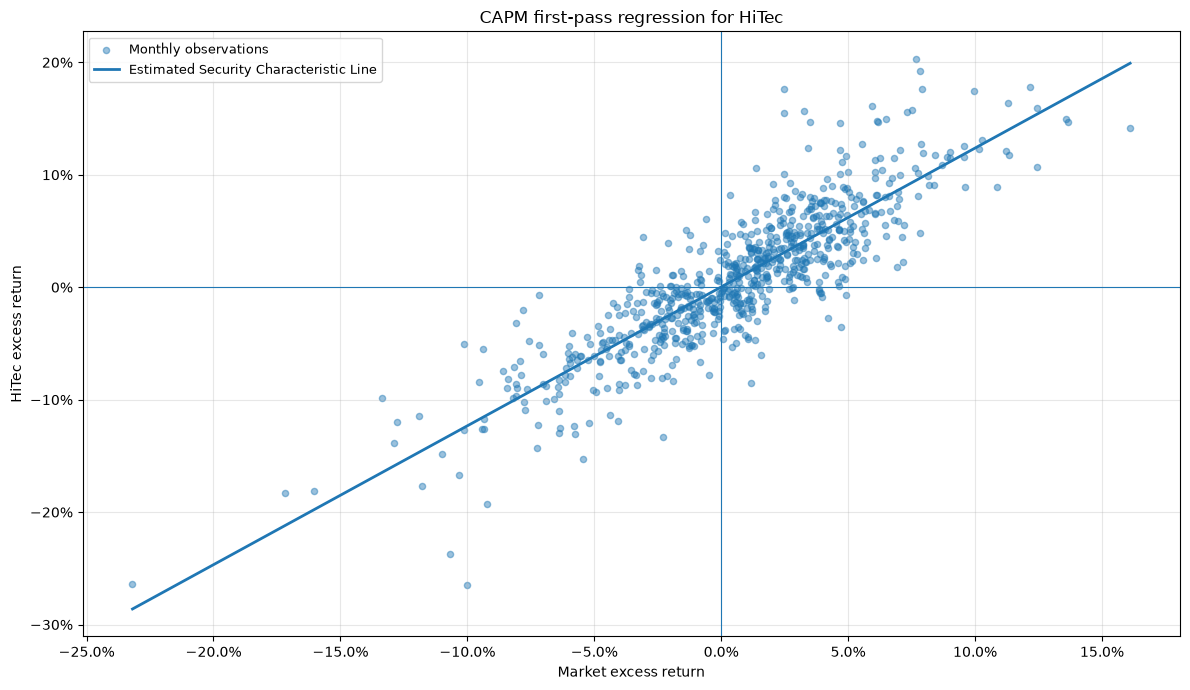

In [24]:
# Plot: Security Characteristic Line

fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(
    asset_data["Mkt-RF"],
    asset_excess,
    alpha=0.45,
    s=20,
    label="Monthly observations",
)
x_grid = np.linspace(
    asset_data["Mkt-RF"].min(), asset_data["Mkt-RF"].max(), 200
)
y_grid = asset_model.params["const"] + asset_model.params["Mkt-RF"] * x_grid
ax.plot(
    x_grid,
    y_grid,
    linewidth=2,
    label="Estimated Security Characteristic Line",
)
ax.axhline(
    0,
    linewidth=0.8,
)
ax.axvline(
    0,
    linewidth=0.8,
)
ax.set_xlabel("Market excess return")
ax.set_ylabel(f"{SELECTED_ASSET} excess return")
ax.set_title(f"CAPM first-pass regression for {SELECTED_ASSET}")
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.grid(
    True,
    alpha=0.3,
)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


Beta captures the part of the asset's risk that moves with the market; the residual is idiosyncratic. In the CAPM, diversified investors are not compensated for the residual component: the required premium is proportional to beta alone.

### **II. Beta of an investor's complete portfolio**

Under two-fund separation, an investor holds the risk-free asset and the market portfolio:

$$R_{C,t}=R_{f,t}+y\bigl(R_{M,t}-R_{f,t}\bigr).$$

Since $\beta_f=0$ and $\beta_M=1$, the complete-portfolio beta is simply $\beta_C=y$: differences in risk tolerance show up as different allocations to the same risky portfolio, not as different risky portfolios. A cautious investor has $0<y<1$, a fully invested one $y=1$, a leveraged one $y>1$.

- Construct complete portfolios for different allocations to the market:

In [25]:
investor_data = factors.loc[ANALYSIS_START:, ["Mkt-RF", "RF"]].dropna()
allocations = np.array([-0.5, 0.0, 0.5, 1.0, 1.5, 2.0])
investor_rows = []

for risky_weight in allocations:
    complete_return = (
        investor_data["RF"] + risky_weight * investor_data["Mkt-RF"]
    )
    model = sm.OLS(
        complete_return - investor_data["RF"],
        sm.add_constant(investor_data[["Mkt-RF"]]),
    ).fit()
    if risky_weight < 0:
        position = "Short market"
    elif risky_weight == 0:
        position = "Risk-free only"
    elif risky_weight < 1:
        position = "Lending / defensive"
    elif risky_weight == 1:
        position = "Market portfolio"
    else:
        position = "Borrowing / leveraged"
    investor_rows.append(
        {
            "Risky-market weight y": risky_weight,
            "Position": position,
            "Theoretical beta": risky_weight,
            "Regression beta": model.params["Mkt-RF"],
            "Annualized mean return": 12 * complete_return.mean(),
            "Annualized volatility": np.sqrt(12) * complete_return.std(ddof=1),
        }
    )


- Compare theoretical and estimated portfolio betas:

In [26]:
investor_beta_table = pd.DataFrame(investor_rows).set_index(
    "Risky-market weight y"
)
display(investor_beta_table.round(4))


,Position,Theoretical beta,Regression beta,Annualized mean return,Annualized volatility
Risky-market weight y,,,,,
-0.5000,Short market,-0.5000,-0.5000,0.0074,0.0785
0.0000,Risk-free only,0.0000,0.0000,0.0435,0.0090
0.5000,Lending / defensive,0.5000,0.5000,0.0796,0.0770
1.0000,Market portfolio,1.0000,1.0000,0.1157,0.1540
1.5000,Borrowing / leveraged,1.5000,1.5000,0.1519,0.2311
2.0000,Borrowing / leveraged,2.0000,2.0000,0.1880,0.3083


#### **Complete-portfolio beta and expected return**

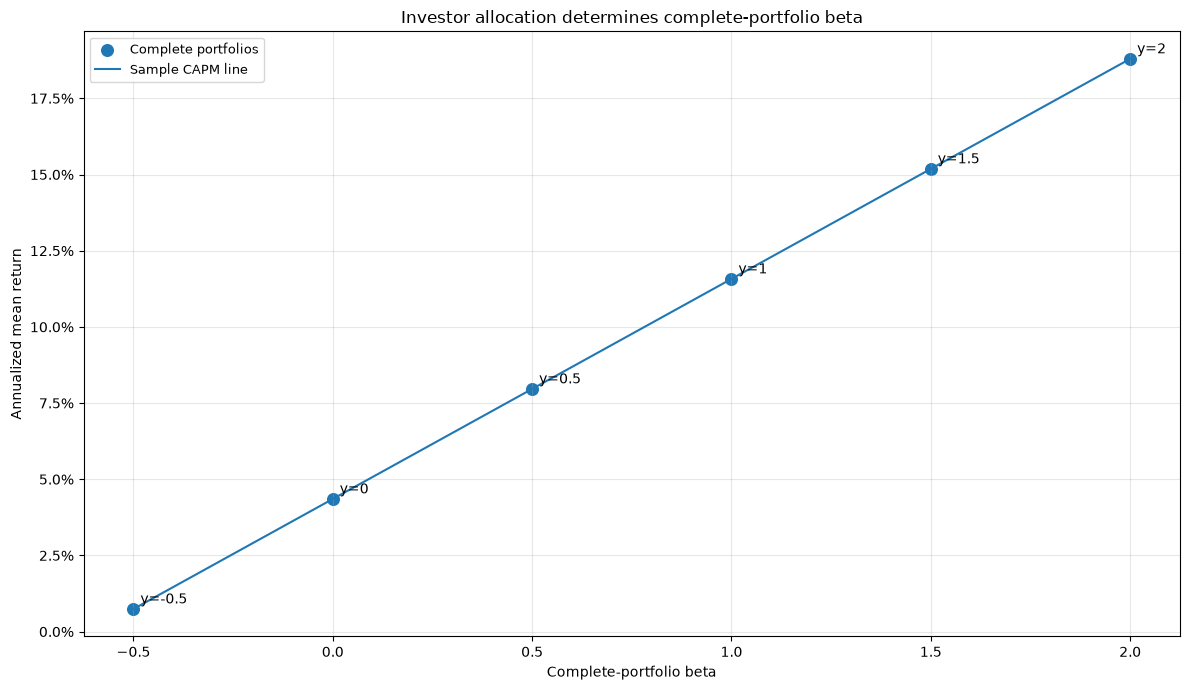

In [27]:
# Plot: Complete-portfolio beta and expected return

fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(
    investor_beta_table["Regression beta"],
    100 * investor_beta_table["Annualized mean return"],
    s=70,
    label="Complete portfolios",
)
for risky_weight, row in investor_beta_table.iterrows():
    ax.annotate(
        f"y={risky_weight:g}",
        (row["Regression beta"], 100 * row["Annualized mean return"]),
        xytext=(5, 4),
        textcoords="offset points",
    )

beta_grid = np.linspace(allocations.min(), allocations.max(), 200)
annual_rf = 12 * investor_data["RF"].mean()
annual_market_premium = 12 * investor_data["Mkt-RF"].mean()
ax.plot(
    beta_grid,
    100 * (annual_rf + beta_grid * annual_market_premium),
    label="Sample CAPM line",
)
ax.set_xlabel("Complete-portfolio beta")
ax.set_ylabel("Annualized mean return")
ax.set_title("Investor allocation determines complete-portfolio beta")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.grid(
    True,
    alpha=0.3,
)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


### **III. Static two-pass test of the CAPM**

The textbook two-pass procedure separates beta estimation from the pricing test.

First pass, time series, one regression per asset:

$$R_{i,t}-R_{f,t}=\alpha_i+\beta_i(R_{M,t}-R_{f,t})+\varepsilon_{i,t}.$$

Second pass, cross section:

$$\overline{R_i-R_f}=\gamma_0+\gamma_1\widehat{\beta}_i+u_i.$$

The CAPM predicts $\gamma_0=0$ and $\gamma_1=\overline{R_M-R_f}$. So "higher beta means higher average return" is not just a positive slope — the slope has to equal the market risk premium. In the summary table below, the p-value in the market-premium row belongs to exactly that restriction, $\gamma_1=\overline{R_M-R_f}$.

Function `first_pass_capm` estimates a separate CAPM regression for each test asset.

In [28]:
def first_pass_capm(
    asset_returns: pd.DataFrame,
    factor_frame: pd.DataFrame,
    start: pd.Timestamp | str = ANALYSIS_START,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    joined = (
        asset_returns.join(factor_frame[["Mkt-RF", "RF"]], how="inner")
        .loc[start:]
        .dropna()
    )
    rows = []
    for asset in asset_returns.columns:
        y = joined[asset] - joined["RF"]
        model = sm.OLS(y, sm.add_constant(joined[["Mkt-RF"]])).fit()
        rows.append(
            {
                "Asset": asset,
                "alpha": model.params["const"],
                "beta": model.params["Mkt-RF"],
                "beta_se": model.bse["Mkt-RF"],
                "residual_sd": model.resid.std(ddof=1),
                "adjusted_R2": model.rsquared_adj,
                "mean_excess_return": y.mean(),
            }
        )
    return pd.DataFrame(rows).set_index("Asset"), joined


- First pass: estimate the 25 portfolio betas:

In [29]:
first_pass_25, p25_capm_data = first_pass_capm(portfolios25, factors)


- Second pass: regress average excess returns on the estimated betas:

In [30]:
second_pass_model = sm.OLS(
    first_pass_25["mean_excess_return"],
    sm.add_constant(first_pass_25[["beta"]]),
).fit()


- Test the intercept and the market risk premium:

In [31]:
sample_market_premium = p25_capm_data["Mkt-RF"].mean()
slope_difference_t = (
    second_pass_model.params["beta"] - sample_market_premium
) / second_pass_model.bse["beta"]
slope_difference_p = 2 * stats.t.sf(
    abs(slope_difference_t), df=second_pass_model.df_resid
)

static_test_summary = pd.DataFrame(
    {
        "Estimate (annualized)": {
            "Second-pass intercept gamma0": 12
            * second_pass_model.params["const"],
            "Second-pass slope gamma1": 12 * second_pass_model.params["beta"],
            "Sample market risk premium": 12 * sample_market_premium,
        },
        "Standard error / comparison": {
            "Second-pass intercept gamma0": 12 * second_pass_model.bse["const"],
            "Second-pass slope gamma1": 12 * second_pass_model.bse["beta"],
            "Sample market risk premium": np.nan,
        },
        "p-value": {
            "Second-pass intercept gamma0": second_pass_model.pvalues["const"],
            "Second-pass slope gamma1": second_pass_model.pvalues["beta"],
            "Sample market risk premium": slope_difference_p,
        },
    }
)

print(
    f"Common sample: {p25_capm_data.index.min():%Y-%m} to {p25_capm_data.index.max():%Y-%m}; "
    f"beta range = {first_pass_25['beta'].min():.3f} to {first_pass_25['beta'].max():.3f}."
)
display(static_test_summary.round(4))


Common sample: 1963-07 to 2026-08; beta range = 0.860 to 1.418.


,Estimate (annualized),Standard error / comparison,p-value
Second-pass intercept gamma0,0.1386,0.0338,0.0004
Second-pass slope gamma1,-0.0431,0.0309,0.1758
Sample market risk premium,0.0722,NaN,0.0011


- Portfolio-level estimates:

In [32]:
display(
    first_pass_25[["beta", "mean_excess_return", "residual_sd", "adjusted_R2"]]
    .sort_values("beta")
    .rename(
        columns={
            "mean_excess_return": "Mean monthly excess return",
            "residual_sd": "Residual SD",
            "adjusted_R2": "Adjusted R2",
        }
    )
    .round(4)
)


,beta,Mean monthly excess return,Residual SD,Adjusted R2
Asset,,,,
ME5 BM3,0.8598,0.0061,0.0204,0.7790
ME5 BM4,0.8835,0.0056,0.0260,0.6963
ME5 BM2,0.9234,0.0059,0.0158,0.8720
ME4 BM4,0.9871,0.0087,0.0247,0.7595
BIG LoBM,0.9909,0.0062,0.0161,0.8831
ME3 BM4,0.9968,0.0087,0.0260,0.7448
BIG HiBM,1.0026,0.0080,0.0359,0.6073
ME4 BM3,1.0091,0.0075,0.0214,0.8147
ME3 BM3,1.0128,0.0075,0.0232,0.7915


#### **Security Market Line**

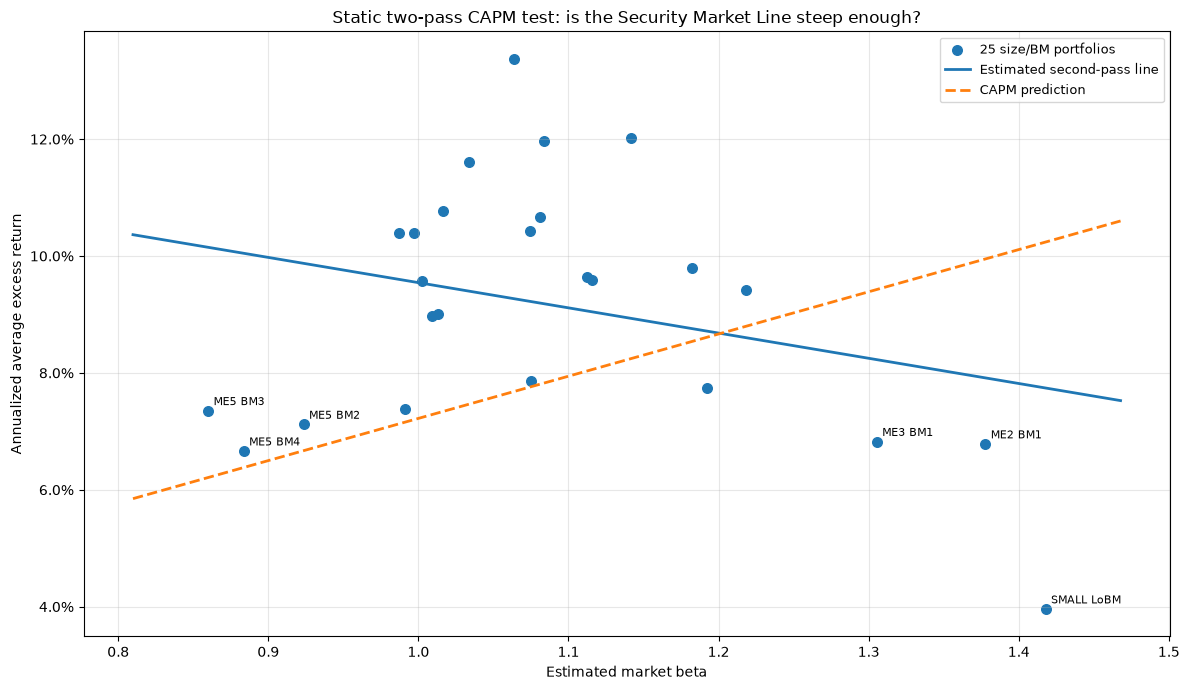

In [33]:
# Plot: Security Market Line

fig, ax = plt.subplots(figsize=(12, 7))
annual_excess = 12 * first_pass_25["mean_excess_return"]
ax.scatter(
    first_pass_25["beta"],
    100 * annual_excess,
    s=48,
    label="25 size/BM portfolios",
)

beta_grid = np.linspace(
    first_pass_25["beta"].min() - 0.05, first_pass_25["beta"].max() + 0.05, 200
)
empirical_line = 12 * (
    second_pass_model.params["const"]
    + second_pass_model.params["beta"] * beta_grid
)
theoretical_line = 12 * sample_market_premium * beta_grid
ax.plot(
    beta_grid,
    100 * empirical_line,
    linewidth=2,
    label="Estimated second-pass line",
)
ax.plot(
    beta_grid,
    100 * theoretical_line,
    linestyle="--",
    linewidth=2,
    label="CAPM prediction",
)

extreme_assets = pd.concat(
    [
        first_pass_25.nsmallest(3, "beta"),
        first_pass_25.nlargest(3, "beta"),
    ]
).drop_duplicates()
for asset, row in extreme_assets.iterrows():
    ax.annotate(
        asset,
        (row["beta"], 100 * 12 * row["mean_excess_return"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_xlabel("Estimated market beta")
ax.set_ylabel("Annualized average excess return")
ax.set_title(
    "Static two-pass CAPM test: is the Security Market Line steep enough?"
)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.grid(
    True,
    alpha=0.3,
)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


#### **Additional CAPM restrictions**

Test whether beta squared and residual volatility explain average returns.

In [34]:
# Extend the second-pass regression

expanded_regressors = first_pass_25[["beta", "residual_sd"]].copy()
expanded_regressors["beta_squared"] = expanded_regressors["beta"] ** 2
expanded_second_pass = sm.OLS(
    first_pass_25["mean_excess_return"],
    sm.add_constant(
        expanded_regressors[["beta", "beta_squared", "residual_sd"]]
    ),
).fit()

expanded_table = pd.DataFrame(
    {
        "Coefficient": expanded_second_pass.params,
        "Standard error": expanded_second_pass.bse,
        "t-statistic": expanded_second_pass.tvalues,
        "p-value": expanded_second_pass.pvalues,
    }
)
expanded_table.index = [
    "Intercept",
    "Beta",
    "Beta squared",
    "Residual volatility",
]
print(
    "CAPM nulls: coefficient on beta squared = 0; coefficient on residual volatility = 0."
)
display(expanded_table.round(4))


CAPM nulls: coefficient on beta squared = 0; coefficient on residual volatility = 0.


,Coefficient,Standard error,t-statistic,p-value
Intercept,-0.0550,0.0090,-6.0933,0.0000
Beta,0.1132,0.0160,7.0737,0.0000
Beta squared,-0.0533,0.0070,-7.6100,0.0000
Residual volatility,0.1179,0.0255,4.6279,0.0001


So, does high beta mean high return? Not in this sample: the second-pass slope is far flatter than the CAPM prediction and even comes out negative. Mind what this does and does not show — it is an empirical rejection for this benchmark and sample, not yet a logically decisive rejection of the theory. Section VI explains why.

#### **Reducing estimation noise with beta-sorted portfolios**

Black-Jensen-Scholes and Fama-MacBeth group securities into portfolios: diversification shrinks residual noise, and sorting on beta preserves cross-sectional dispersion. The price is fewer observations in the second pass.

The next cell estimates formation-period betas (1963-1989), sorts the 25 portfolios into five groups, and tests the beta-return relation out of sample from 1990 on.

- Form five beta-sorted portfolios using the formation sample:

In [36]:
FORMATION_END = pd.Timestamp("1989-12-01")
TEST_START = pd.Timestamp("1990-01-01")
BETA_GROUP_LABELS = [
    "Beta 1 (low)",
    "Beta 2",
    "Beta 3",
    "Beta 4",
    "Beta 5 (high)",
]

formation_returns = portfolios25.loc[ANALYSIS_START:FORMATION_END]
formation_factors = factors.loc[:FORMATION_END]
formation_first_pass, _ = first_pass_capm(formation_returns, formation_factors)

beta_groups = pd.qcut(
    formation_first_pass["beta"].rank(method="first"),
    5,
    labels=BETA_GROUP_LABELS,
)

test_portfolios = pd.DataFrame(
    {
        label: portfolios25.loc[
            TEST_START:, beta_groups[beta_groups == label].index
        ].mean(axis=1)
        for label in BETA_GROUP_LABELS
    }
)


- Estimate betas and the second-pass line in the test sample:

In [37]:
test_first_pass, test_capm_data = first_pass_capm(
    test_portfolios, factors.loc[TEST_START:], start=TEST_START
)
test_second_pass = sm.OLS(
    test_first_pass["mean_excess_return"],
    sm.add_constant(test_first_pass[["beta"]]),
).fit()


- Compare the out-of-sample results:

In [38]:
beta_group_results = test_first_pass[
    ["beta", "mean_excess_return", "residual_sd"]
].copy()
beta_group_results["Annualized mean excess return"] = (
    12 * beta_group_results["mean_excess_return"]
)
beta_group_results["CAPM-predicted annual excess return"] = (
    12 * test_capm_data["Mkt-RF"].mean() * beta_group_results["beta"]
)

print(
    f"Formation period: {formation_returns.index.min():%Y-%m} to {formation_returns.index.max():%Y-%m}"
)
print(
    f"Test period: {test_capm_data.index.min():%Y-%m} to {test_capm_data.index.max():%Y-%m}"
)
display(
    pd.DataFrame({"Formation beta group": beta_groups}).sort_values(
        "Formation beta group"
    )
)
display(beta_group_results.drop(columns="mean_excess_return").round(4))


Formation period: 1963-07 to 1989-12
Test period: 1990-01 to 2026-08


,Formation beta group
Asset,
BIG HiBM,Beta 1 (low)
ME5 BM3,Beta 1 (low)
ME4 BM4,Beta 1 (low)
ME3 BM4,Beta 1 (low)
ME5 BM4,Beta 1 (low)
ME5 BM2,Beta 2
BIG LoBM,Beta 2
ME4 BM3,Beta 2
ME3 BM3,Beta 2


,beta,residual_sd,Annualized mean excess return,CAPM-predicted annual excess return
Asset,,,,
Beta 1 (low),0.9804,0.0223,0.0975,0.0881
Beta 2,0.9713,0.0131,0.0984,0.0873
Beta 3,1.0485,0.0301,0.1166,0.0942
Beta 4,1.1017,0.0220,0.1046,0.0990
Beta 5 (high),1.2690,0.0365,0.0844,0.1140


#### **Out-of-sample beta-sorted portfolios**

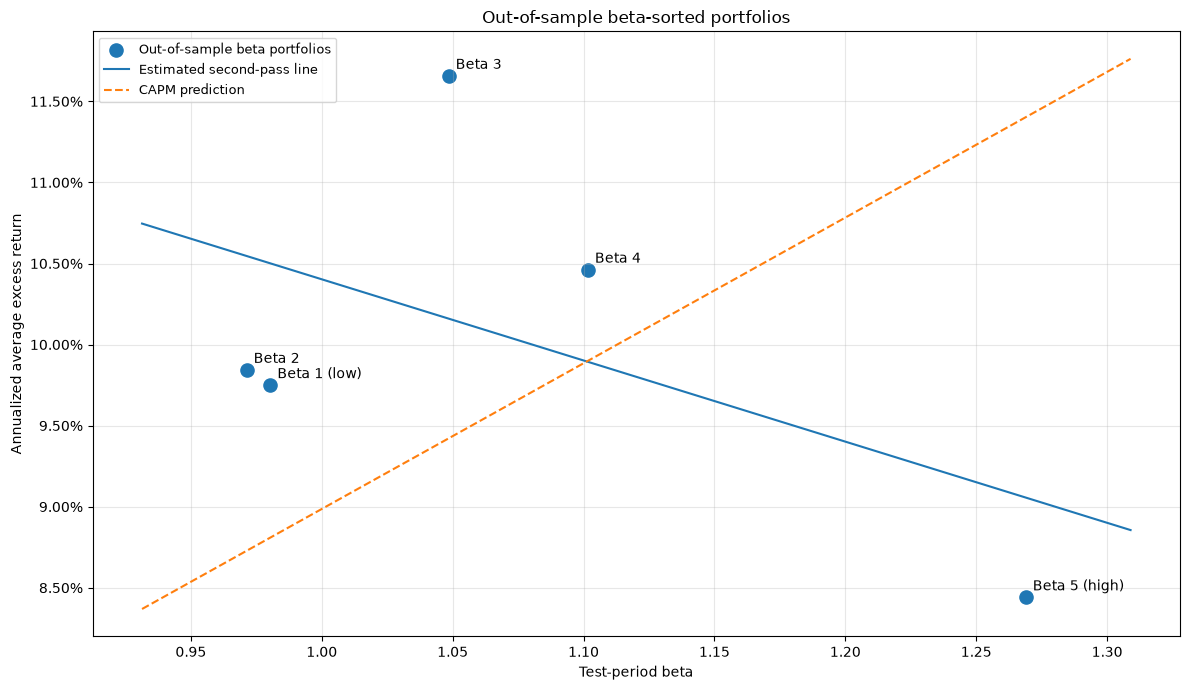

In [39]:
# Plot: Out-of-sample beta-sorted portfolios

fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(
    beta_group_results["beta"],
    100 * beta_group_results["Annualized mean excess return"],
    s=90,
    label="Out-of-sample beta portfolios",
)
for label, row in beta_group_results.iterrows():
    ax.annotate(
        label,
        (row["beta"], 100 * row["Annualized mean excess return"]),
        xytext=(5, 5),
        textcoords="offset points",
    )

beta_grid = np.linspace(
    beta_group_results["beta"].min() - 0.04,
    beta_group_results["beta"].max() + 0.04,
    200,
)
empirical = 12 * (
    test_second_pass.params["const"]
    + test_second_pass.params["beta"] * beta_grid
)
theoretical = 12 * test_capm_data["Mkt-RF"].mean() * beta_grid
ax.plot(
    beta_grid,
    100 * empirical,
    label="Estimated second-pass line",
)
ax.plot(
    beta_grid,
    100 * theoretical,
    linestyle="--",
    label="CAPM prediction",
)
ax.set_xlabel("Test-period beta")
ax.set_ylabel("Annualized average excess return")
ax.set_title("Out-of-sample beta-sorted portfolios")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.grid(
    True,
    alpha=0.3,
)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


### **IV. Fama-MacBeth rolling two-pass test**

The static test treats betas and average returns as fixed quantities. Fama-MacBeth instead repeats the exercise every month: estimate each portfolio's beta from a trailing window, regress the next month's returns on those betas, and use the time series of monthly slopes $\gamma_{1,t}$ for inference.

Below, a 60-month rolling first pass on the 25 size/book-to-market portfolios.

Function `fama_macbeth_capm` estimates trailing-window betas and the following month’s cross-sectional regression.

In [41]:
def fama_macbeth_capm(
    asset_returns: pd.DataFrame,
    factor_frame: pd.DataFrame,
    window: int = ROLLING_WINDOW,
    start: pd.Timestamp | str = ANALYSIS_START,
) -> pd.DataFrame:
    data = (
        asset_returns.join(factor_frame[["Mkt-RF", "RF"]], how="inner")
        .loc[start:]
        .dropna()
    )
    assets = list(asset_returns.columns)
    records = []

    for position in range(window, len(data)):
        history = data.iloc[position - window : position]
        market = history["Mkt-RF"].to_numpy()
        market_centered = market - market.mean()
        denominator = np.dot(market_centered, market_centered)

        excess_history = history[assets].sub(history["RF"], axis=0).to_numpy()
        excess_centered = excess_history - excess_history.mean(axis=0)
        beta_hat = (market_centered[:, None] * excess_centered).sum(
            axis=0
        ) / denominator

        current_excess_return = data.iloc[position][assets].to_numpy(
            dtype=float
        ) - float(data.iloc[position]["RF"])
        cross_section = sm.OLS(
            current_excess_return, sm.add_constant(beta_hat)
        ).fit()

        records.append(
            {
                "Date": data.index[position],
                "gamma0": cross_section.params[0],
                "gamma1": cross_section.params[1],
                "mean_beta": beta_hat.mean(),
                "beta_dispersion": beta_hat.std(ddof=1),
            }
        )

    return pd.DataFrame(records).set_index("Date")


Function `hac_mean_test` tests a time-series mean with HAC standard errors.

In [42]:
def hac_mean_test(
    series: pd.Series, null: float = 0.0, maxlags: int = 6
) -> dict[str, float]:
    clean = series.dropna().astype(float)
    model = sm.OLS(clean.to_numpy(), np.ones((len(clean), 1))).fit(
        cov_type="HAC", cov_kwds={"maxlags": maxlags}
    )
    estimate = float(model.params[0])
    standard_error = float(model.bse[0])
    t_stat = (estimate - null) / standard_error
    p_value = 2 * stats.norm.sf(abs(t_stat))
    return {
        "estimate": estimate,
        "standard_error": standard_error,
        "t_stat": t_stat,
        "p_value": p_value,
        "observations": len(clean),
    }


- Run the rolling regressions and test their average coefficients:

In [43]:
fm_coefficients = fama_macbeth_capm(portfolios25, factors)
fm_market_premium = factors.loc[fm_coefficients.index, "Mkt-RF"]

intercept_test = hac_mean_test(fm_coefficients["gamma0"])
slope_test = hac_mean_test(fm_coefficients["gamma1"])
slope_minus_market_test = hac_mean_test(
    fm_coefficients["gamma1"] - fm_market_premium
)


- Average intercept, slope, and market premium:

In [44]:
fm_summary = pd.DataFrame(
    {
        "Annualized estimate": {
            "Average gamma0": 12 * intercept_test["estimate"],
            "Average gamma1": 12 * slope_test["estimate"],
            "Average market premium": 12 * fm_market_premium.mean(),
            "Average gamma1 minus market premium": 12
            * slope_minus_market_test["estimate"],
        },
        "Annualized HAC standard error": {
            "Average gamma0": 12 * intercept_test["standard_error"],
            "Average gamma1": 12 * slope_test["standard_error"],
            "Average market premium": np.nan,
            "Average gamma1 minus market premium": 12
            * slope_minus_market_test["standard_error"],
        },
        "t-statistic": {
            "Average gamma0": intercept_test["t_stat"],
            "Average gamma1": slope_test["t_stat"],
            "Average market premium": np.nan,
            "Average gamma1 minus market premium": slope_minus_market_test[
                "t_stat"
            ],
        },
        "p-value": {
            "Average gamma0": intercept_test["p_value"],
            "Average gamma1": slope_test["p_value"],
            "Average market premium": np.nan,
            "Average gamma1 minus market premium": slope_minus_market_test[
                "p_value"
            ],
        },
    }
)

print(f"Monthly cross-sectional regressions: {len(fm_coefficients)}")
display(fm_summary.round(4))


Monthly cross-sectional regressions: 698


,Annualized estimate,Annualized HAC standard error,t-statistic,p-value
Average gamma0,0.1133,0.0332,3.4109,0.0006
Average gamma1,-0.0275,0.0363,-0.7583,0.4483
Average market premium,0.0713,NaN,NaN,NaN
Average gamma1 minus market premium,-0.0988,0.0326,-3.0321,0.0024


#### **Rolling beta risk premium**

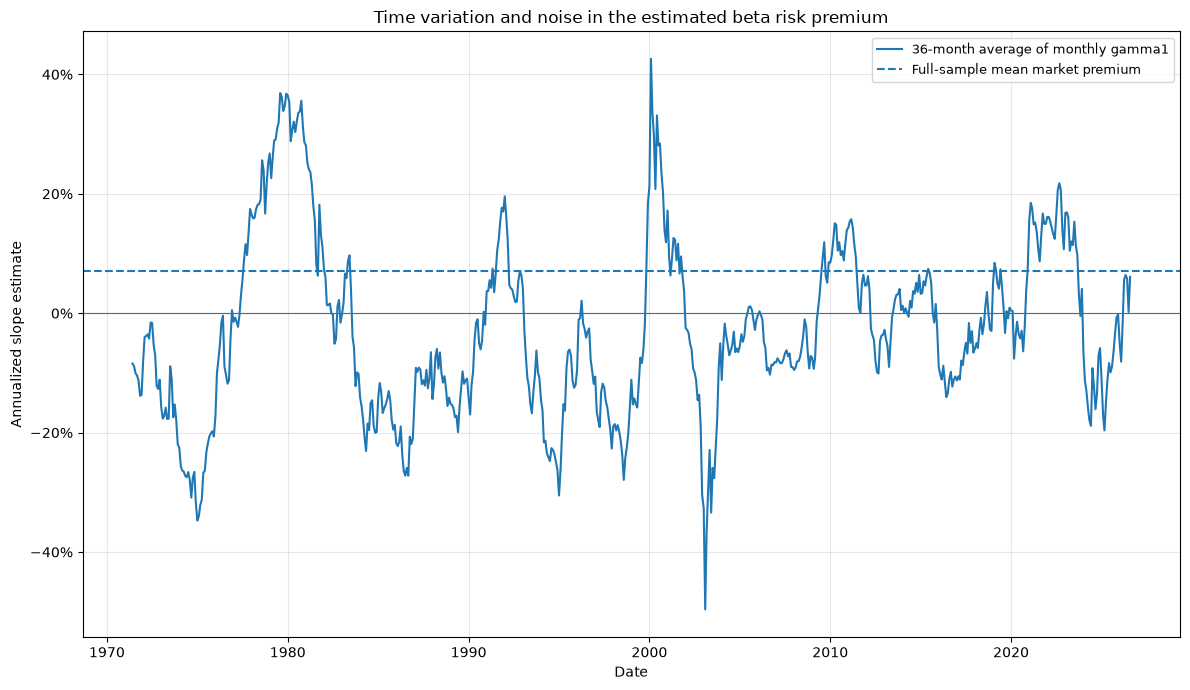

In [45]:
# Plot: Rolling beta risk premium

fig, ax = plt.subplots(figsize=(12, 7))
rolling_gamma1 = 12 * fm_coefficients["gamma1"].rolling(36).mean()
ax.plot(
    rolling_gamma1.index,
    100 * rolling_gamma1,
    label="36-month average of monthly gamma1",
)
ax.axhline(
    100 * 12 * fm_market_premium.mean(),
    linestyle="--",
    label="Full-sample mean market premium",
)
ax.axhline(
    0,
    linewidth=0.8,
)
ax.set_ylabel("Annualized slope estimate")
ax.set_xlabel("Date")
ax.set_title("Time variation and noise in the estimated beta risk premium")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.grid(
    True,
    alpha=0.3,
)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


A positive average $\gamma_1$ would support a positive beta-return relation; the sharper CAPM restriction is that it equals the market premium, with a zero intercept. Here the average slope is statistically indistinguishable from zero and reliably below the premium. The rolling plot shows how much the estimate moves around; short samples can support very different conclusions.

### **V. Why the estimated SML is too flat: measurement error in beta**

The second-pass regressor is not the true beta, only a first-pass estimate. Classical errors-in-variables logic then says the second-pass slope is biased toward zero and the intercept is biased upward; longer estimation windows and diversified test portfolios reduce the problem.

The simulation below builds returns that satisfy the CAPM exactly, and still gets a flattened SML when the first-pass window is short.

Function `simulate_two_pass_measurement_error` compares second-pass slopes based on true and estimated betas.

In [46]:
def simulate_two_pass_measurement_error(
    n_replications: int = 500,
    n_assets: int = 100,
    n_months: int = 60,
    market_premium: float = 0.006,
    market_volatility: float = 0.045,
    residual_volatility: float = 0.09,
    seed: int = RANDOM_SEED,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed + n_months)
    true_beta = np.linspace(0.30, 1.80, n_assets)
    records = []

    for _ in range(n_replications):
        market = rng.normal(market_premium, market_volatility, n_months)
        residual = rng.normal(
            0.0, residual_volatility, size=(n_months, n_assets)
        )
        asset_excess = market[:, None] * true_beta[None, :] + residual

        market_centered = market - market.mean()
        asset_centered = asset_excess - asset_excess.mean(axis=0)
        estimated_beta = (market_centered[:, None] * asset_centered).sum(
            axis=0
        ) / np.dot(market_centered, market_centered)

        average_returns = asset_excess.mean(axis=0)
        estimated_beta_regression = np.linalg.lstsq(
            np.column_stack([np.ones(n_assets), estimated_beta]),
            average_returns,
            rcond=None,
        )[0]
        true_beta_regression = np.linalg.lstsq(
            np.column_stack([np.ones(n_assets), true_beta]),
            average_returns,
            rcond=None,
        )[0]

        records.append(
            {
                "Intercept using estimated beta": estimated_beta_regression[0],
                "Slope using estimated beta": estimated_beta_regression[1],
                "Slope using true beta": true_beta_regression[1],
            }
        )

    return pd.DataFrame(records)


- Simulate 60-month and 240-month estimation windows:

In [48]:
simulation_60 = simulate_two_pass_measurement_error(n_months=60)
simulation_240 = simulate_two_pass_measurement_error(n_months=240)
THEORETICAL_PREMIUM = 0.006


- Compare the annualized simulation results:

In [49]:
simulation_summary = pd.DataFrame(
    {
        "60-month first pass": {
            "Mean intercept using estimated beta": 12
            * simulation_60["Intercept using estimated beta"].mean(),
            "Mean slope using estimated beta": 12
            * simulation_60["Slope using estimated beta"].mean(),
            "Mean slope using true beta": 12
            * simulation_60["Slope using true beta"].mean(),
            "Theoretical market premium": 12 * THEORETICAL_PREMIUM,
        },
        "240-month first pass": {
            "Mean intercept using estimated beta": 12
            * simulation_240["Intercept using estimated beta"].mean(),
            "Mean slope using estimated beta": 12
            * simulation_240["Slope using estimated beta"].mean(),
            "Mean slope using true beta": 12
            * simulation_240["Slope using true beta"].mean(),
            "Theoretical market premium": 12 * THEORETICAL_PREMIUM,
        },
    }
)
display(simulation_summary.round(4))


,60-month first pass,240-month first pass
Mean intercept using estimated beta,0.0198,0.0055
Mean slope using estimated beta,0.0546,0.0655
Mean slope using true beta,0.0754,0.0709
Theoretical market premium,0.0720,0.0720


#### **Measurement error in beta**

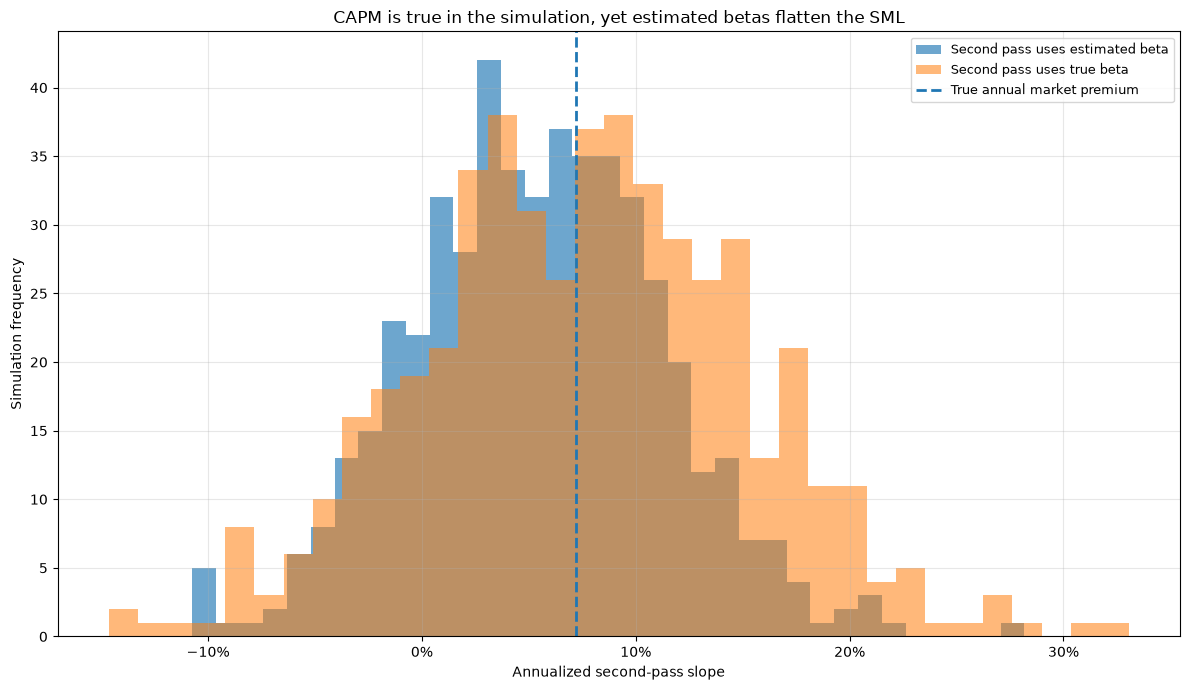

In [50]:
# Plot: Measurement error in beta

fig, ax = plt.subplots(figsize=(12, 7))
ax.hist(
    100 * 12 * simulation_60["Slope using estimated beta"],
    bins=35,
    alpha=0.65,
    label="Second pass uses estimated beta",
)
ax.hist(
    100 * 12 * simulation_60["Slope using true beta"],
    bins=35,
    alpha=0.55,
    label="Second pass uses true beta",
)
ax.axvline(
    100 * 12 * THEORETICAL_PREMIUM,
    linestyle="--",
    linewidth=2,
    label="True annual market premium",
)
ax.set_xlabel("Annualized second-pass slope")
ax.set_ylabel("Simulation frequency")
ax.set_title(
    "CAPM is true in the simulation, yet estimated betas flatten the SML"
)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.grid(
    True,
    alpha=0.3,
)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


### **VI. Roll's critique and the market portfolio**

Roll's point of departure: the CAPM's one central testable implication is the mean-variance efficiency of the true market portfolio, which contains all assets, not just a stock index. Every empirical test uses a proxy. A rejection may only mean the proxy is inefficient; a non-rejection may mean the proxy happens to be efficient in this sample. Beta and alpha are benchmark-dependent objects.

The experiment: re-estimate every industry's beta and alpha against (1) the French market factor `Mkt-RF` and (2) an equal-weighted average of the ten industry portfolios.

- Estimate each industry’s beta and alpha under both market proxies:

In [51]:
proxy_data = (
    industries.join(factors[["Mkt-RF", "RF"]], how="inner")
    .loc[ANALYSIS_START:]
    .dropna()
)
proxy_data["EW10-RF"] = (
    proxy_data[industries.columns].mean(axis=1) - proxy_data["RF"]
)

proxy_rows = []
for asset in industries.columns:
    asset_excess_return = proxy_data[asset] - proxy_data["RF"]
    for proxy in ["Mkt-RF", "EW10-RF"]:
        model = sm.OLS(
            asset_excess_return, sm.add_constant(proxy_data[[proxy]])
        ).fit()
        proxy_rows.append(
            {
                "Asset": asset,
                "Proxy": proxy,
                "Alpha": model.params["const"],
                "Beta": model.params[proxy],
                "Adjusted R2": model.rsquared_adj,
            }
        )


- Compare the benchmark-dependent estimates:

In [52]:
proxy_results = pd.DataFrame(proxy_rows)
proxy_beta = proxy_results.pivot(index="Asset", columns="Proxy", values="Beta")
proxy_alpha = 12 * proxy_results.pivot(
    index="Asset", columns="Proxy", values="Alpha"
)
proxy_comparison = pd.DataFrame(
    {
        "Beta: official market": proxy_beta["Mkt-RF"],
        "Beta: EW industry proxy": proxy_beta["EW10-RF"],
        "Beta difference": proxy_beta["EW10-RF"] - proxy_beta["Mkt-RF"],
        "Annual alpha: official market": proxy_alpha["Mkt-RF"],
        "Annual alpha: EW industry proxy": proxy_alpha["EW10-RF"],
        "Annual alpha difference": proxy_alpha["EW10-RF"]
        - proxy_alpha["Mkt-RF"],
    }
)

print(
    f"Correlation between the two market proxies: {proxy_data[['Mkt-RF', 'EW10-RF']].corr().iloc[0, 1]:.4f}"
)
display(proxy_comparison.round(4))


Correlation between the two market proxies: 0.9797


,Beta: official market,Beta: EW industry proxy,Beta difference,Annual alpha: official market,Annual alpha: EW industry proxy,Annual alpha difference
Asset,,,,,,
Durbl,1.2507,1.3757,0.1250,-0.0102,-0.0239,-0.0138
Enrgy,0.8395,0.9441,0.1046,0.0223,0.0115,-0.0108
HiTec,1.2349,1.2098,-0.0251,0.0028,0.0005,-0.0024
Hlth,0.8085,0.8648,0.0562,0.0253,0.0182,-0.0070
Manuf,1.0352,1.1006,0.0654,0.0000,-0.0085,-0.0085
NoDur,0.7608,0.8455,0.0847,0.0220,0.0129,-0.0090
Other,1.0900,1.1551,0.0650,-0.0069,-0.0156,-0.0087
Shops,0.9994,1.0611,0.0617,0.0123,0.0042,-0.0081
Telcm,0.7698,0.8333,0.0635,-0.0027,-0.0101,-0.0075


#### **Market-proxy comparison**

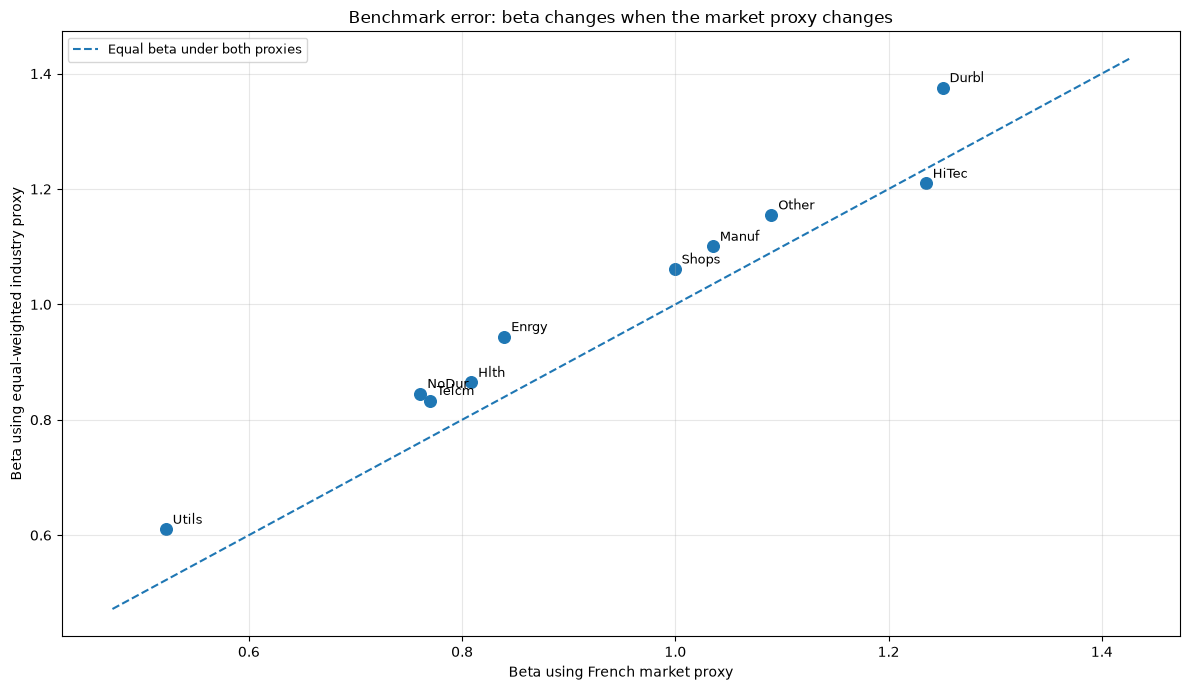

In [53]:
# Plot: Market-proxy comparison

fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(
    proxy_comparison["Beta: official market"],
    proxy_comparison["Beta: EW industry proxy"],
    s=70,
)
minimum_beta = (
    proxy_comparison[["Beta: official market", "Beta: EW industry proxy"]]
    .min()
    .min()
    - 0.05
)
maximum_beta = (
    proxy_comparison[["Beta: official market", "Beta: EW industry proxy"]]
    .max()
    .max()
    + 0.05
)
ax.plot(
    [minimum_beta, maximum_beta],
    [minimum_beta, maximum_beta],
    linestyle="--",
    label="Equal beta under both proxies",
)
for asset, row in proxy_comparison.iterrows():
    ax.annotate(
        asset,
        (row["Beta: official market"], row["Beta: EW industry proxy"]),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=9,
    )
ax.set_xlabel("Beta using French market proxy")
ax.set_ylabel("Beta using equal-weighted industry proxy")
ax.set_title("Benchmark error: beta changes when the market proxy changes")
ax.grid(
    True,
    alpha=0.3,
)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


The two proxies correlate at 0.98 and still produce noticeably different betas and alphas — a manager with positive alpha under one benchmark can lose it under the other. Since the true market portfolio is unobservable, any CAPM test is a joint test of the model and the benchmark.

---

## **FAMA-FRENCH: FACTOR CONSTRUCTION AND REGRESSIONS**

### **VII. Constructing the Fama-French SMB and HML factors**

The construction starts from six value-weighted portfolios, a 2×3 sort on size and book-to-market (Small/Big crossed with Low/Neutral/High). The zero-investment factors are

$$\text{SMB}=\tfrac{1}{3}(S/L+S/N+S/H)-\tfrac{1}{3}(B/L+B/N+B/H),$$

$$\text{HML}=\tfrac{1}{2}(S/H+B/H)-\tfrac{1}{2}(S/L+B/L).$$

SMB is long small and short big; HML is long value (high book-to-market) and short growth. Both are zero-net-investment long-short portfolios, so their return is already a premium and no risk-free rate gets subtracted.

- Construct SMB and HML from the six size/book-to-market portfolios:

In [54]:
reconstructed_factors = pd.DataFrame(index=portfolios6.index)
reconstructed_factors["SMB reconstructed"] = portfolios6[
    ["Small Low", "Small Neutral", "Small High"]
].mean(axis=1) - portfolios6[["Big Low", "Big Neutral", "Big High"]].mean(
    axis=1
)
reconstructed_factors["HML reconstructed"] = 0.5 * (
    portfolios6["Small High"] + portfolios6["Big High"]
) - 0.5 * (portfolios6["Small Low"] + portfolios6["Big Low"])
reconstructed_factors = reconstructed_factors.join(
    factors[["SMB", "HML"]], how="inner"
).dropna()


- Compare the reconstructed and published factors:

In [55]:
factor_construction_summary = pd.DataFrame(
    {
        "SMB": {
            "Correlation with official factor": reconstructed_factors[
                "SMB reconstructed"
            ].corr(reconstructed_factors["SMB"]),
            "Mean absolute difference (monthly bps)": 10_000
            * (
                reconstructed_factors["SMB reconstructed"]
                - reconstructed_factors["SMB"]
            )
            .abs()
            .mean(),
            "Mean reconstructed premium (annualized)": 12
            * reconstructed_factors["SMB reconstructed"].mean(),
            "Mean official premium (annualized)": 12
            * reconstructed_factors["SMB"].mean(),
        },
        "HML": {
            "Correlation with official factor": reconstructed_factors[
                "HML reconstructed"
            ].corr(reconstructed_factors["HML"]),
            "Mean absolute difference (monthly bps)": 10_000
            * (
                reconstructed_factors["HML reconstructed"]
                - reconstructed_factors["HML"]
            )
            .abs()
            .mean(),
            "Mean reconstructed premium (annualized)": 12
            * reconstructed_factors["HML reconstructed"].mean(),
            "Mean official premium (annualized)": 12
            * reconstructed_factors["HML"].mean(),
        },
    }
)

print(
    f"Comparison sample: {reconstructed_factors.index.min():%Y-%m} to {reconstructed_factors.index.max():%Y-%m}"
)
display(factor_construction_summary.round(4))


Comparison sample: 1926-07 to 2026-08


,SMB,HML
Correlation with official factor,1.0000,1.0000
Mean absolute difference (monthly bps),0.2586,0.2525
Mean reconstructed premium (annualized),0.0199,0.0422
Mean official premium (annualized),0.0199,0.0422


#### **Cumulative HML returns**

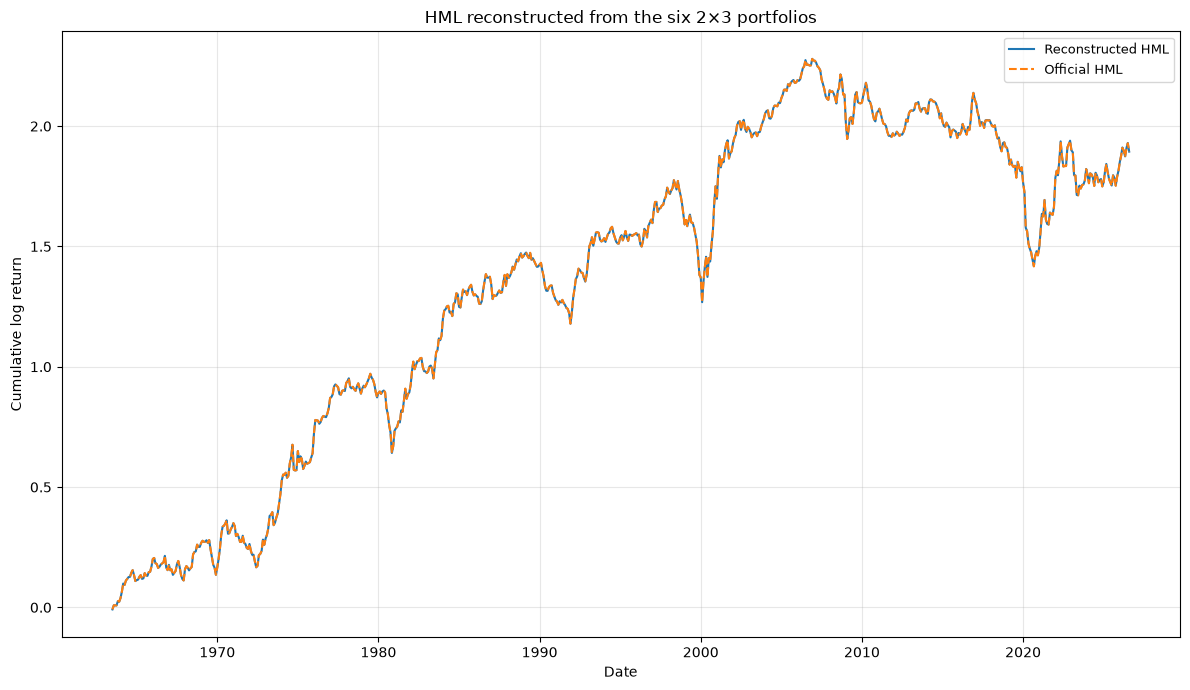

In [57]:
# Plot: Cumulative HML returns

plot_start = max(ANALYSIS_START, reconstructed_factors.index.min())
log_cumulative_hml = np.log1p(
    reconstructed_factors.loc[plot_start:, ["HML reconstructed", "HML"]]
).cumsum()
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(
    log_cumulative_hml.index,
    log_cumulative_hml["HML reconstructed"],
    label="Reconstructed HML",
)
ax.plot(
    log_cumulative_hml.index,
    log_cumulative_hml["HML"],
    linestyle="--",
    label="Official HML",
)
ax.set_ylabel("Cumulative log return")
ax.set_xlabel("Date")
ax.set_title("HML reconstructed from the six 2×3 portfolios")
ax.grid(
    True,
    alpha=0.3,
)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


#### **Cumulative SMB returns**

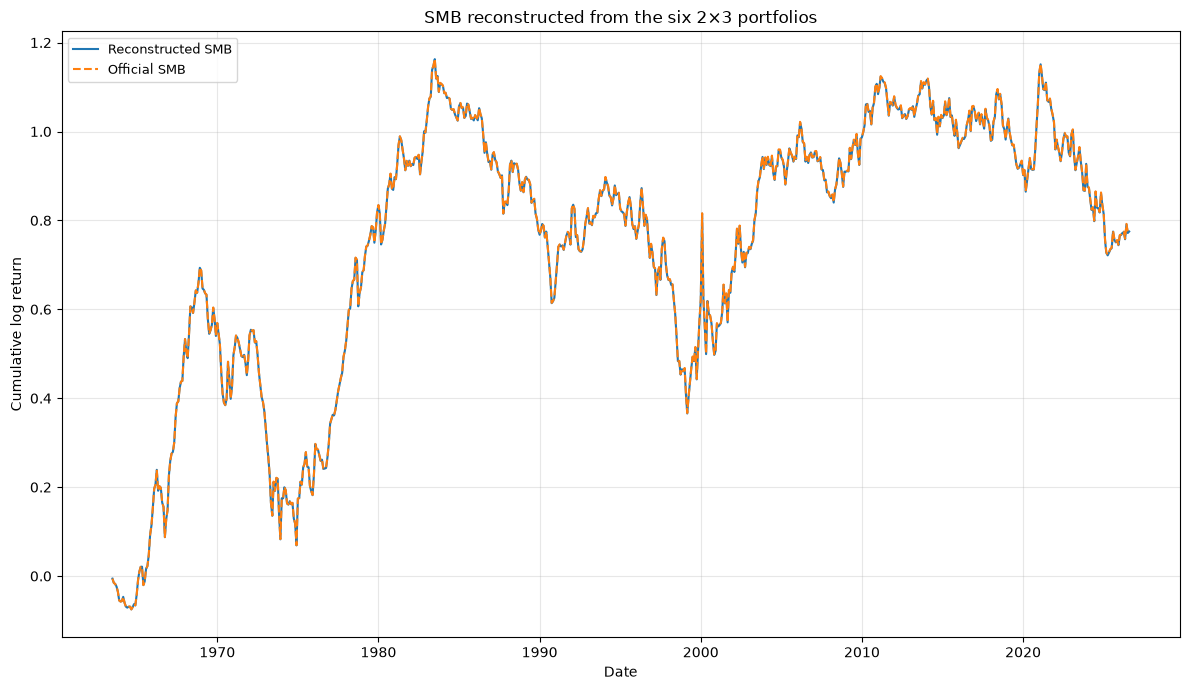

In [58]:
# Plot: Cumulative SMB returns

log_cumulative_smb = np.log1p(
    reconstructed_factors.loc[plot_start:, ["SMB reconstructed", "SMB"]]
).cumsum()
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(
    log_cumulative_smb.index,
    log_cumulative_smb["SMB reconstructed"],
    label="Reconstructed SMB",
)
ax.plot(
    log_cumulative_smb.index,
    log_cumulative_smb["SMB"],
    linestyle="--",
    label="Official SMB",
)
ax.set_ylabel("Cumulative log return")
ax.set_xlabel("Date")
ax.set_title("SMB reconstructed from the six 2×3 portfolios")
ax.grid(
    True,
    alpha=0.3,
)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


Small discrepancies are expected here: the bundled files come from different vintages, and French's historical series get revised when CRSP data or the construction changes. Correlations this close to one are what "the formulas are right" looks like in practice.

### **VIII. Fama-French three-factor regressions**

The time-series model is

$$R_{i,t}-R_{f,t}=\alpha_i+\beta_i(R_{M,t}-R_{f,t})+s_i\,SMB_t+h_i\,HML_t+\varepsilon_{i,t}.$$

A positive $s_i$ says the asset behaves like small stocks, a positive $h_i$ like value stocks, and $\alpha_i$ is whatever average return the three factors leave unexplained. Keep in mind the regression only measures exposures; it cannot tell whether SMB and HML reward risk or exploit persistent mispricing.

- Estimate CAPM and Fama-French models for the selected industry:

In [59]:
capm_selected, selected_capm_data, selected_excess = fit_time_series_model(
    industries[SELECTED_ASSET], factors, ["Mkt-RF"]
)
ff3_selected, selected_ff3_data, _ = fit_time_series_model(
    industries[SELECTED_ASSET], factors, ["Mkt-RF", "SMB", "HML"]
)


- Compare alpha, factor exposures, and model fit:

In [60]:
selected_model_comparison = pd.DataFrame(
    {
        "CAPM": {
            "Annualized alpha": 12 * capm_selected.params["const"],
            "Market beta": capm_selected.params["Mkt-RF"],
            "SMB loading": np.nan,
            "HML loading": np.nan,
            "Adjusted R-squared": capm_selected.rsquared_adj,
            "Annualized residual volatility": np.sqrt(12)
            * capm_selected.resid.std(ddof=1),
        },
        "Fama–French 3": {
            "Annualized alpha": 12 * ff3_selected.params["const"],
            "Market beta": ff3_selected.params["Mkt-RF"],
            "SMB loading": ff3_selected.params["SMB"],
            "HML loading": ff3_selected.params["HML"],
            "Adjusted R-squared": ff3_selected.rsquared_adj,
            "Annualized residual volatility": np.sqrt(12)
            * ff3_selected.resid.std(ddof=1),
        },
    }
)

print(f"Model comparison for {SELECTED_ASSET}")
display(selected_model_comparison.round(4))


Model comparison for HiTec


,CAPM,Fama–French 3
Annualized alpha,0.0028,0.0265
Market beta,1.2349,1.1249
SMB loading,NaN,0.1767
HML loading,NaN,-0.5348
Adjusted R-squared,0.7496,0.8185
Annualized residual volatility,0.1101,0.0936


- Three-factor regression coefficients:

In [61]:
ff3_inference = pd.DataFrame(
    {
        "Estimate": ff3_selected.params,
        "HAC standard error": ff3_selected.bse,
        "t-statistic": ff3_selected.tvalues,
        "p-value": ff3_selected.pvalues,
    }
)
ff3_inference.index = [
    "Alpha (monthly)",
    "Market beta",
    "SMB loading",
    "HML loading",
]
display(ff3_inference.round(4))


,Estimate,HAC standard error,t-statistic,p-value
Alpha (monthly),0.0022,0.0010,2.1749,0.0296
Market beta,1.1249,0.0349,32.1975,0.0000
SMB loading,0.1767,0.0452,3.9059,0.0001
HML loading,-0.5348,0.0618,-8.6585,0.0000


Function `compare_capm_and_ff3` estimates both models on a common sample for each test asset.

In [ ]:
def compare_capm_and_ff3(
    asset_returns: pd.DataFrame,
    factor_frame: pd.DataFrame,
    start: pd.Timestamp | str = ANALYSIS_START,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    joined = (
        asset_returns.join(
            factor_frame[["Mkt-RF", "SMB", "HML", "RF"]], how="inner"
        )
        .loc[start:]
        .dropna()
    )
    rows = []
    for asset in asset_returns.columns:
        y = joined[asset] - joined["RF"]
        capm = sm.OLS(y, sm.add_constant(joined[["Mkt-RF"]])).fit()
        ff3 = sm.OLS(y, sm.add_constant(joined[["Mkt-RF", "SMB", "HML"]])).fit()
        rows.append(
            {
                "Asset": asset,
                "CAPM alpha": capm.params["const"],
                "CAPM beta": capm.params["Mkt-RF"],
                "CAPM adjusted R2": capm.rsquared_adj,
                "FF3 alpha": ff3.params["const"],
                "FF3 market beta": ff3.params["Mkt-RF"],
                "FF3 SMB loading": ff3.params["SMB"],
                "FF3 HML loading": ff3.params["HML"],
                "FF3 adjusted R2": ff3.rsquared_adj,
                "CAPM residual SD": capm.resid.std(ddof=1),
                "FF3 residual SD": ff3.resid.std(ddof=1),
            }
        )
    return pd.DataFrame(rows).set_index("Asset"), joined


- Factor loadings for the ten industries:

In [ ]:
industry_model_comparison, industry_ff_data = compare_capm_and_ff3(
    industries, factors
)
industry_loadings = industry_model_comparison[
    ["FF3 market beta", "FF3 SMB loading", "FF3 HML loading"]
]

display(industry_loadings.round(3))


#### **Industry factor loadings**

In [ ]:
# Plot: Industry factor loadings

fig, ax = plt.subplots(figsize=(12, 7))
image = ax.imshow(
    industry_loadings.to_numpy(),
    aspect="auto",
)
fig.colorbar(
    image,
    ax=ax,
    label="Estimated loading",
)
ax.set_xticks(
    range(industry_loadings.shape[1]),
    industry_loadings.columns,
    rotation=25,
    ha="right",
)
ax.set_yticks(
    range(industry_loadings.shape[0]),
    industry_loadings.index,
)
for row in range(industry_loadings.shape[0]):
    for column in range(industry_loadings.shape[1]):
        ax.text(
            column,
            row,
            f"{industry_loadings.iloc[row, column]:.2f}",
            ha="center",
            va="center",
            fontsize=9,
            color=(
                "white"
                if image.norm(industry_loadings.iloc[row, column]) < 0.5
                else "black"
            ),
        )
ax.set_title("Fama–French factor loadings across ten industries")
fig.tight_layout()
plt.show()


- Calculate predicted average returns for the 25 size/book-to-market portfolios:

In [ ]:
portfolio_model_comparison, p25_ff_data = compare_capm_and_ff3(
    portfolios25, factors
)
factor_means = factors.loc[p25_ff_data.index, ["Mkt-RF", "SMB", "HML"]].mean()
actual_mean_excess = (
    p25_ff_data[portfolios25.columns].sub(p25_ff_data["RF"], axis=0).mean()
)

capm_predicted_mean = (
    portfolio_model_comparison["CAPM beta"] * factor_means["Mkt-RF"]
)
ff3_predicted_mean = (
    portfolio_model_comparison["FF3 market beta"] * factor_means["Mkt-RF"]
    + portfolio_model_comparison["FF3 SMB loading"] * factor_means["SMB"]
    + portfolio_model_comparison["FF3 HML loading"] * factor_means["HML"]
)


- Compare pricing errors and model fit:

In [ ]:
comparison_summary = pd.DataFrame(
    {
        "CAPM": {
            "Mean absolute annualized alpha": 12
            * portfolio_model_comparison["CAPM alpha"].abs().mean(),
            "Median adjusted R-squared": portfolio_model_comparison[
                "CAPM adjusted R2"
            ].median(),
            "Annualized pricing RMSE": 12
            * np.sqrt(np.mean((actual_mean_excess - capm_predicted_mean) ** 2)),
            "Median annualized residual volatility": np.sqrt(12)
            * portfolio_model_comparison["CAPM residual SD"].median(),
        },
        "Fama–French 3": {
            "Mean absolute annualized alpha": 12
            * portfolio_model_comparison["FF3 alpha"].abs().mean(),
            "Median adjusted R-squared": portfolio_model_comparison[
                "FF3 adjusted R2"
            ].median(),
            "Annualized pricing RMSE": 12
            * np.sqrt(np.mean((actual_mean_excess - ff3_predicted_mean) ** 2)),
            "Median annualized residual volatility": np.sqrt(12)
            * portfolio_model_comparison["FF3 residual SD"].median(),
        },
    }
)

print(
    f"25-portfolio comparison sample: {p25_ff_data.index.min():%Y-%m} to {p25_ff_data.index.max():%Y-%m}"
)
display(comparison_summary.round(4))


#### **CAPM and Fama-French model fit**

In [ ]:
# Plot: CAPM and Fama-French model fit

fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(
    portfolio_model_comparison["CAPM adjusted R2"],
    portfolio_model_comparison["FF3 adjusted R2"],
    s=55,
)
minimum_r2 = (
    min(
        portfolio_model_comparison["CAPM adjusted R2"].min(),
        portfolio_model_comparison["FF3 adjusted R2"].min(),
    )
    - 0.03
)
maximum_r2 = (
    max(
        portfolio_model_comparison["CAPM adjusted R2"].max(),
        portfolio_model_comparison["FF3 adjusted R2"].max(),
    )
    + 0.03
)
ax.plot(
    [minimum_r2, maximum_r2],
    [minimum_r2, maximum_r2],
    linestyle="--",
    label="Equal fit",
)
ax.set_xlabel("CAPM adjusted R-squared")
ax.set_ylabel("FF3 adjusted R-squared")
ax.set_title("Does adding SMB and HML improve the time-series fit?")
ax.grid(
    True,
    alpha=0.3,
)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


#### **Actual and predicted portfolio returns**

In [ ]:
# Plot: Actual and predicted portfolio returns

fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(
    100 * 12 * actual_mean_excess,
    100 * 12 * capm_predicted_mean,
    s=58,
    label="CAPM prediction",
)
ax.scatter(
    100 * 12 * actual_mean_excess,
    100 * 12 * ff3_predicted_mean,
    marker="x",
    s=70,
    label="FF3 prediction",
)
axis_min = (
    100
    * 12
    * min(
        actual_mean_excess.min(),
        capm_predicted_mean.min(),
        ff3_predicted_mean.min(),
    )
    - 0.5
)
axis_max = (
    100
    * 12
    * max(
        actual_mean_excess.max(),
        capm_predicted_mean.max(),
        ff3_predicted_mean.max(),
    )
    + 0.5
)
ax.plot(
    [axis_min, axis_max],
    [axis_min, axis_max],
    linestyle="--",
    label="Perfect pricing",
)
ax.set_xlabel("Actual annualized mean excess return")
ax.set_ylabel("Model-predicted annualized mean excess return")
ax.set_title("CAPM versus FF3 pricing of the 25 size/book-to-market portfolios")
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.grid(
    True,
    alpha=0.3,
)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


For portfolios sorted on size and book-to-market, FF3 raises adjusted $R^2$, cuts residual volatility, and shrinks pricing errors — unsurprising, since these are exactly the spreads the extra factors were built to capture. For individual industries the improvement is smaller, and an alpha can even grow: see HiTec above, where the strongly negative HML loading raises the three-factor alpha.